
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E00_linear_regression.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Linear regression exercises

---
These are introductory exercises in Machine learning with focus in **linear regression** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate phone dataset (*)

We want to simulate data $(x,y)$ to represent cost for phone subscriptions, with: 

- $x$ - called minutes per month
- $y$ - SEK per month 

&nbsp; a) Use ```numpy.random.normal()``` to simulate a dataset with the following requirements:(*)
- set a seed to 42 (for reproducibility and reference)
- simulate 400 x-values from the r.v. $X \sim \mathcal{N}(100, 100)$ 
- take absolute value of these x-values
- simulate noise 400 noise values from r.v. $\epsilon \sim \mathcal{N(0, 50)}$ 
- Let $y = 2x+25+\epsilon$
- plot the data set 

&nbsp; b) Now we want to remove some outliers according to this assumption: (*)
- no one talks more than 300 min using this type of subscription
- no ones costs can be negative
- plot the new dataset
- also plot ground truth using the true parameters $\beta_0 = 25, \beta_1 = 2$

&nbsp; c) Insert the values into a DataFrame (*)

<details>

<summary>Answer</summary>

<img src="../assets/simulated_phone_dataset_0.png" height="200"/>

a) 

Number of points x ≥ 300 min: 8

Number of points y < 0 kr: 6


b)

Length of x, outliers removed 386

Length of y, outliers removed 386

c)

df.head()

|    |   Minutes |     Cost |
|---:|----------:|---------:|
|  0 |   59.4428 | 168.721  |
|  1 |   40.0625 |  98.2118 |
|  2 |  100.524  | 258.433  |
|  3 |  104.698  | 310.548  |
|  4 |   54.9935 | 123.279  |


</details>

---

Number of x-values above 300: 11
Number of y-values below: 8


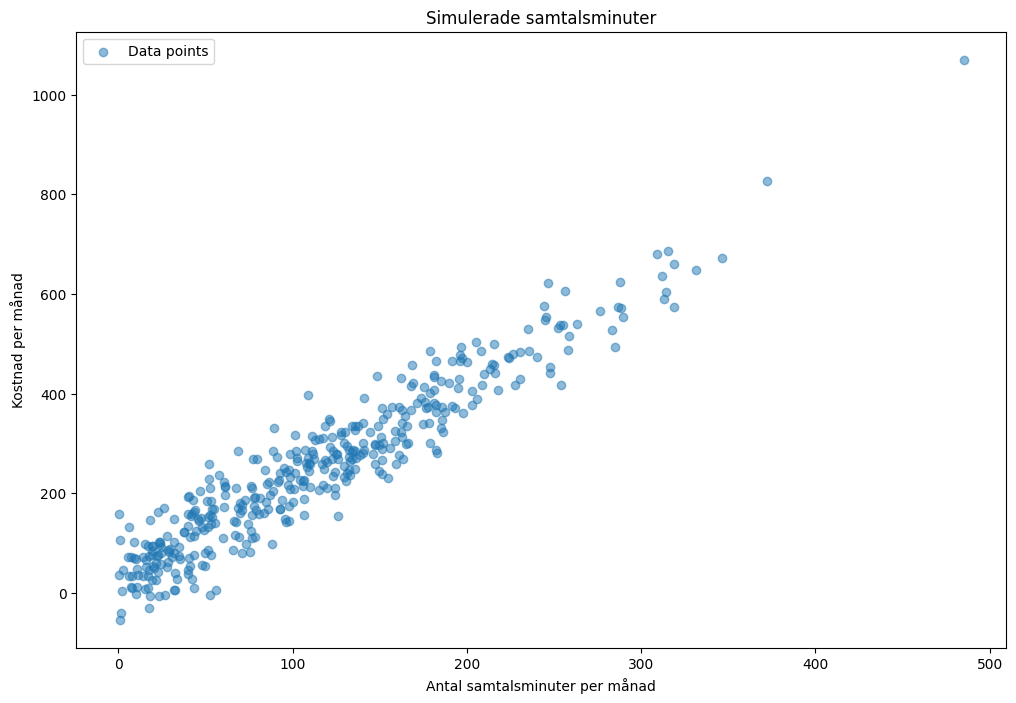

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# x = called minutes per month
# y = SEK per month

# a

# När vi sätter ett "seed" så kommer vi få samma värden varje gång vi kör samma slumpgenerator.
# Detta är användbart när vi vill ha samma värden för att kunna jämföra olika metoder.
# Vi kan också använda detta för att kunna återskapa samma resultat vid ett senare tillfälle.

np.random.seed(42)

# np.random.normal ger oss ett slumpmässigt värde från en normalfördelning.
# loc = medelvärdet
# scale = standardavvikelsen
# size = antalet värden
# bonus - r.v betyder "random variable"

x = np.random.normal(loc=100, scale=100, size=400)

x_values = np.abs(x)

epsilon = np.random.normal(loc=0, scale=50, size=400)

y = 2 * x_values + 25 + epsilon

num_x_above_300 = np.sum(x_values > 300)
print(f"Number of x-values above 300: {num_x_above_300}")

num_y_below_0 = np.sum(y < 0)
print(f"Number of y-values below: {num_y_below_0}")

plt.figure(figsize=(12, 8))
plt.scatter(x_values, y, alpha=0.5, label="Data points")
plt.xlabel("Antal samtalsminuter per månad")
plt.ylabel("Kostnad per månad")
plt.title("Simulerade samtalsminuter")
plt.legend()
plt.show()

Number of x-values with outliers removed: 381
Number of y-values with outliers removed: 381


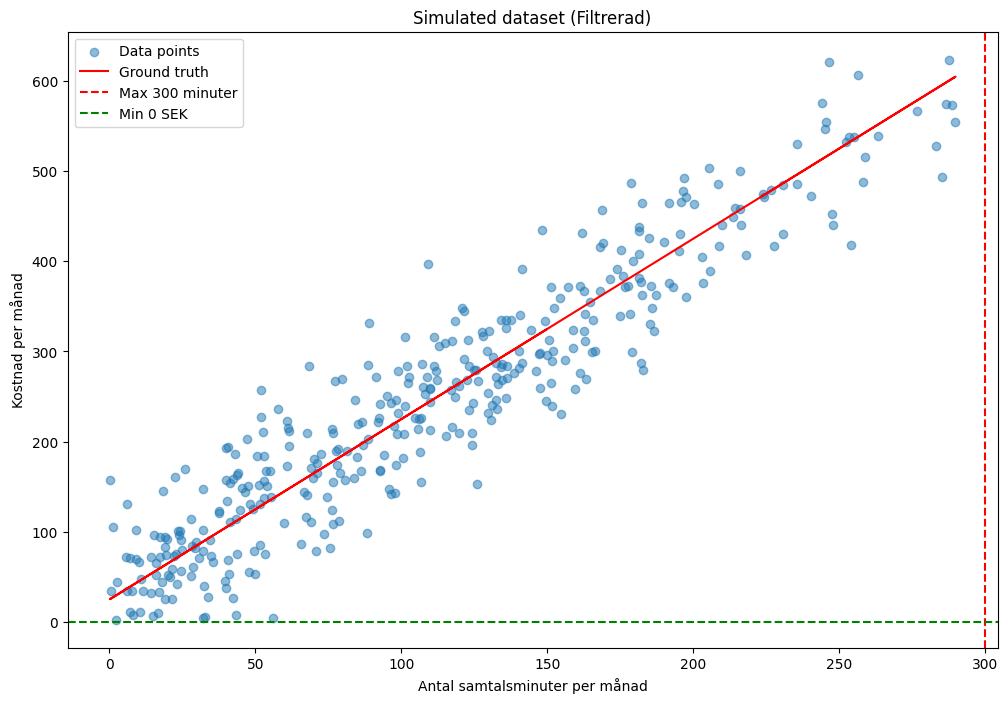

In [22]:
max_x = x_values <= 300


min_y = y >= 0


new_plot = max_x & min_y


x_filtered = x_values[new_plot]
y_filtered = y[new_plot]

# Ground truth är den "sanna" funktionen som vi använder för att skapa våra data.
# I detta fall är det en linjär funktion som vi skapade tidigare.
ground_truth = 2 * x_filtered + 25

print(f"Number of x-values with outliers removed: {len(x_filtered)}")
print(f"Number of y-values with outliers removed: {len(y_filtered)}")

plt.figure(figsize=(12, 8))
plt.scatter(x_filtered, y_filtered, alpha=0.5, label="Data points")
plt.plot(x_filtered, ground_truth, color='r', label="Ground truth")
plt.xlabel("Antal samtalsminuter per månad")
plt.ylabel("Kostnad per månad")
plt.title("Simulated dataset (Filtrerad)")
plt.axvline(x=300, color='r', linestyle='--', label="Max 300 minuter")
plt.axhline(y=0, color='g', linestyle='--', label="Min 0 SEK")
plt.legend()
plt.show()

In [23]:
df = pd.DataFrame({'Minutes': x_filtered, 'Cost': y_filtered})
df.head()

,Minutes,Cost
0,149.671415,244.621448
1,86.173570,167.378389
2,164.768854,354.799893
3,252.302986,531.955001
4,76.584663,155.666051


## 1. Train|test split (*)

Before moving on with linear regression we shall first perform a train-test-split. 

&nbsp; a) Create a train-test-split function with the following call signature: (*)

```py
def train_test_split(X: pd.DataFrame, y: pd.DataFrame, train_fraction=.7: float, random_state=42: int, replace=False: bool) -> tuple
```

that returns the tuple:
```
(X_train, X_test, y_train, y_test)
```

&nbsp; b) Now use this to split up your data into a training set and test set. Check manually that the split is performed correctly. (*)


<details>

<summary>Hint</summary>

b) Check the length of each set, and check the indices of the sorted sets that they don't overlap and are not missing. Also check that they sum up to what you expect.

</details>

<br/>

<details>

<summary>Answer</summary>

Using default 0.7: 
- length of X_train: 270
- length of X_test: 116
- length of y_train: 270
- length of X_test: 116

</details>

---

In [24]:
def train_test_split(X: pd.DataFrame, y: pd.DataFrame, train_fraction: float = 0.7, random_state: int = 42, replace: bool = False) -> tuple:
    # Denna funktion delar upp våra data i en träningsmängd och en testmängd.
    # Vi börjar med att slumpa ordningen på våra data.

    # Reminder för mitt febriga jag: 

    # X är våra features, dvs de variabler som vi använder för att göra en prediktion.
    # y är våra target values, dvs de värden som vi vill prediktera.
    # T.ex om vi gör pannkakor så är X våra ingredienser och y är mängden pannkakor.

    # Train_fraction är andelen exempel som ska vara i träningsmängden, dvs 0.7 = 70%.
    # Random_state är seeden för slumpgeneratorn.
    # Replace är en bool som avgör om vi ska byta ut exempel eller inte. 

    # Index är kolumnen längst till vänster i en DataFrame, som är unik för varje rad. 
    # Det är ett unikt id för varje rad i datasetet.

    np.random.seed(random_state)

    # Train size är antalet exempel som ska vara i träningsmängden, aka antalet rader i datasetet (n).
    # Vi tar alltså längden på X (vår DataFrame) och multiplicerar med 0.7 (vår train_fraction).
    # T.ex om vi har 100 rader och train_fraction är 0.7 så blir train_size = 70.
    train_size = int(len(X) * train_fraction)

    # Train indices är de index som ska vara i träningsmängden, valda slumpmässigt. 
    # T.ex om vi har 100 rader i X och vår train_size är 70 så kommer vi välja 70 index slumpmässigt.
    train_indices = np.random.choice(X.index, size=train_size, replace=replace)

    # .loc är en metod för att välja ut rader i en DataFrame baserat på index. 
    # Man kan se ".loc" som en "location" för rader i en DataFrame.

    # Allmänt format för .loc är: DataFrame.loc[row_selection, column_selection]

    # Här väljer vi ut de rader som har index som finns i train_indices.
    # Dessa rader kommer alltså vara i träningsmängden.

    X_train = X.loc[train_indices]
    y_train = y.loc[train_indices]

    # Här väljer vi ut de rader som inte finns i train_indices, så att vi inte blandar tränings- och testdata.
    # Dessa rader kommer alltså vara i testmängden.
    X_test = X.drop(train_indices)
    y_test = y.drop(train_indices)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(df[['Minutes']], df['Cost'])
print(f"Number of training examples (X_train): {len(X_train)}")
print(f"Number of test examples (X_test): {len(X_test)}")
print(f"Number of training targets(y_train): {len(y_train)}")
print(f"Number of test targets(y_test): {len(y_test)}")


Number of training examples (X_train): 266
Number of test examples (X_test): 115
Number of training targets(y_train): 266
Number of test targets(y_test): 115


## 2. Simple linear regression with normal equation (*)

Use the normal equation for simple linear regression to solve for the coefficients $\hat{\beta} = (\beta_0, \beta_1)$. Note that you should only use the training data to fit the regression line, and not data from the test set. Plot the the regression line, together with ground truth and training data. 

<details>

<summary>Hint</summary>

It is important to keep track of the shapes of the vectors, matrices in order for matrix multiplication matmul "@" to work correctly. Also, if you have series object, you need to convert it to numpy. 

</details>

<br/>

<details>

<summary>Answer</summary>


<img src="../assets/Reg_line_normal_eq.png" height="200"/>

</details>

---

(np.float64(32.2214772186936), np.float64(1.910505914786177))


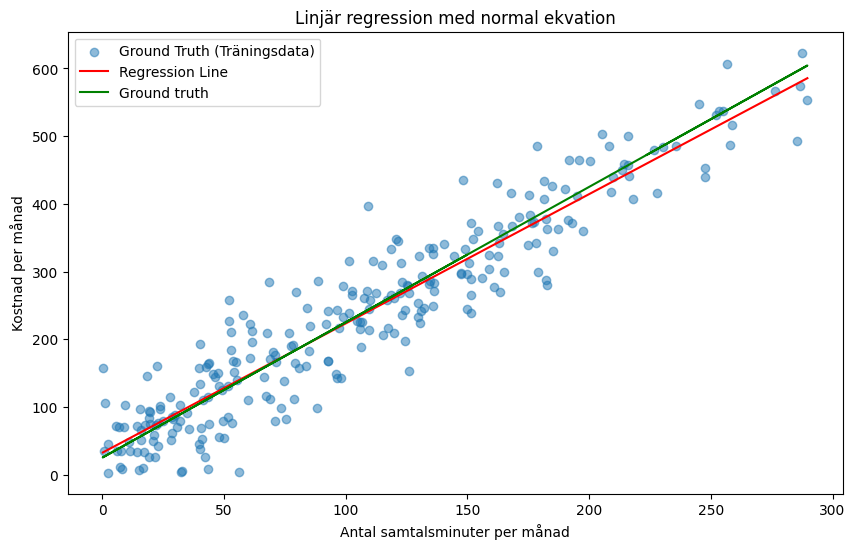

In [25]:
# Normalekvationen för simpel linjär regression: y = β0 ​+ β1​x + ϵ
# I matrisform: β^​ = (XT * X)-1 * XT * y
# β0 = intercept 
# β1 = coefficient
# ϵ = error term(epsilon)

def normal_equation(X_train, y_train):
    # Vi vill ta in X_train och y_train och returnera β0 och β1.

    # Vi börjar med att lägga till en kolumn med 1:or i X_train.
    # Detta är för att vi ska kunna räkna ut interceptet (β0) i normala ekvationen.
    x = np.c_[np.ones(X_train.shape[0]), X_train]

    # Här använder vi formeln för normala ekvationen (i matrisform) för att räkna ut β0 och β1.
    beta = np.linalg.inv(x.T @ x) @ x.T @ y_train

    return beta[0], beta[1]

print(normal_equation(X_train, y_train))

# beta0 och beta1 används för att rita den linjära regressionslinjen.
beta0, beta1 = normal_equation(X_train, y_train)

# x_line ritar ut 100 värden mellan minsta och största värdet i X_train.
x_line = np.linspace(X_train.min(), X_train.max(), 100)

# Denna linje är den linje som bäst passar våra data, baserat på minsta kvadratmetoden.
y_line = beta0 + beta1 * x_line

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.5, label="Ground Truth (Träningsdata)")


plt.plot(x_line, y_line, color='red', label="Regression Line")
plt.plot(x_filtered, ground_truth, color='green', label="Ground truth")


plt.xlabel("Antal samtalsminuter per månad")
plt.ylabel("Kostnad per månad")
plt.title("Linjär regression med normal ekvation")
plt.legend()
plt.show()

## 3. Prediction and evaluation (*)

&nbsp; a) Use your model to make prediction on testing data. Plot the prediction cost against X_test, and y_test against X_test. (*)

&nbsp; b) Calculate MAE, MSE, RMSE (*)

<details>

<summary>Hint</summary>

Calculate y_pred from X_test and use y_test and y_pred to compute different evaluation metrics.

Careful with dimensions when computing the evaluation metrics, else it can be catastrophical logical errors due to numpy broadcasting feature.

Note that after you have calculate the error metrics on test data you are not allowed to change any parameters to make the line fit better to the testing data.

</details>

<br/>

<details>

<summary>Answer</summary>

a) 

<img src="../assets/eval_simple_lin_reg.png" height="200"/>

b)

Mean absolute error on testing data: 36.97 kr

Mean squared error on testing data: 2374 kr^2

Root mean squared error on testing data: 48.72 kr

</details>

---

# Felmått för Linjär Regression

#### 🟢 1. Mean Absolute Error (MAE)
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
- **Medelvärdet av alla absoluta fel.**
- Ger en tydlig tolkning: *"Hur mycket fel gör modellen i genomsnitt per observation?"*
- Ingen kvadrering, vilket gör att stora fel **inte** straffas extra.

---

#### 🟢 2. Mean Squared Error (MSE)
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
- **Kvadrerar felen innan vi tar medelvärdet.**
- **Straffar större fel extra mycket**, vilket gör det känsligt för outliers.
- Svårare att tolka direkt eftersom felet är i kvadrat.

---

#### 🟢 3. Root Mean Squared Error (RMSE)
$$
\text{RMSE} = \sqrt{\text{MSE}}
$$
- **Tar roten ur MSE**, vilket gör det lättare att tolka.
- Har fortfarande kvar egenskapen att **större fel straffas mer**.
- Anges i samma enhet som y-värdena.

---



MAE: 40.12
MSE: 2401.58
RMSE: 49.01


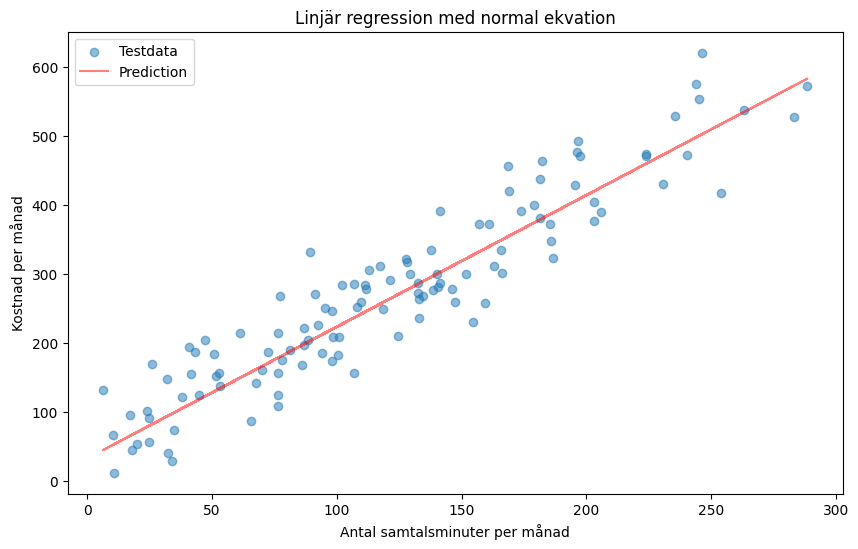

In [26]:
# Dags att göra en prediktion på testdatan!


def predict(X_test, beta0, beta1):
    # Denna funktion tar in testdatan och β0 och β1 och returnerar en lista med förutsagda värden.
    # Detta gör vi med hjälp av formeln för linjär regression: y = β0 + β1x
    return beta0 + beta1 * X_test

y_pred = predict(X_test, beta0, beta1)

# Vi använder .to_numpy() för att konvertera våra pandas Series till numpy arrays.
# Vi använder sedan .flatten() för att göra om vår array till en 1D-array.
y_pred = y_pred.to_numpy().flatten()

# Vi kan nu räkna ut MAE (Mean Absolute Error) för vår modell.
# Vi gör detta genom att ta medelvärdet av absolutbeloppet av skillnaden mellan prediktion och sanning.
MAE = np.mean(np.abs(y_pred - y_test))

# Vi kan också räkna ut MSE (Mean Squared Error) och RMSE (Root Mean Squared Error) för vår modell.
# MSE är medelvärdet av kvadraten på skillnaden mellan prediktion och sanning.
MSE = np.mean((y_pred - y_test) ** 2)

# RMSE är kvadratroten av MSE.
RMSE = np.sqrt(MSE)



print(f"MAE: {MAE:.2f}")
print(f"MSE: {MSE:.2f}")
print(f"RMSE: {RMSE:.2f}")


plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.5, label="Testdata")
plt.plot(X_test, y_pred, color='red', alpha=0.5, label="Prediction")

plt.xlabel("Antal samtalsminuter per månad")
plt.ylabel("Kostnad per månad")
plt.title("Linjär regression med normal ekvation")
plt.legend()
plt.show()

## 4. Simulate more explanatory variables (\*)

Now we will simulate the explanatory variables for minutes, text messages and amount of surf. For reference and reproducibility use numpy random seed 42. Assume there is:

- mean start cost: 25kr
- mean cost per minute: 2kr
- mean cost per sms: 50 öre
- mean cost per GB: 50kr

Then the model for the cost will be:
$y = 25 + 2x_1 + 0.5x_2 + 50x_3 + \epsilon$, where

- $x_i$ sampled from r.v. $X_i$ for $i = \{1,2,3\}$
- $X_1 \sim |\mathcal{N}(100,100)|$, (absolute value)
- $X_2 \sim \mathcal{U}(0,50)$, (discrete uniform distribution)
- $X_3 \sim |\mathcal{N}(0,2)|$,
- $\epsilon \sim \mathcal{N}(0,50)$

&nbsp; a) Simulate 10000 samples of each of $x_1, x_2, x_3$ and $y$ and save them in a DataFrame. Also add an intercept column containing ones. (\*)

&nbsp; b) Make histograms for each of the explanatory variables $x_1, x_2, x_3$ and the response variable $y$ (\*)

&nbsp; c) Clean the data using the following constraints (\*)

- surf should be less than 4
- minutes should be less than 300
- cost should be larger than 0

&nbsp; d) Make new histograms for the variables. (\*)

<details>

<summary>Hint</summary>
Your data analysis skill toolbox together with statistics and linear algebra skills are getting quite handy here.

</details>

<br/>

<details>

<summary>Answer</summary>

a)

|      | Intercept | Minutes | SMS | Surf (GB) |    Cost |
| ---: | --------: | ------: | --: | --------: | ------: |
|    0 |         1 | 149.671 |  41 |   2.26301 | 502.396 |
|    1 |         1 | 86.1736 |  16 | 0.0315695 | 179.072 |
|  ... |       ... |     ... | ... |       ... |     ... |
| 9318 |         1 | 149.577 |  31 |   3.43929 | 536.176 |
| 9319 |         1 | 164.439 |  43 |   1.40641 | 406.674 |

b)

<img src="../assets/hist_variables.png" height="200"/>

d)

<img src="../assets/hist_var_cleaned.png" height="200"/>

</details>

---


In [27]:
# I denna uppgift så ska vi simulera flera förklarande variabler.
# Vi gör detta genom att använda denna model: y = 25 + 2x1 ​+ 0.5x2 ​+ 10x3 ​+ ϵ
# Där:
    # x1​ ∼ N(100,100), absolutbelopp av normalfördelning.
    # x2​ ∼ U(0, 50), normalfördelning.
    # x3 ​∼ ∣N(0,2)∣, absolutbelopp av normalfördelning.
    # ϵ∼N(0,50), normalfördelat brus.
        # brus är slumpmässiga fel i våra data.
        # Vi kan se detta som slumpmässiga fel i mätningar, t.ex. att en våg inte är helt exakt.
        # Brus behövs för att göra våra modeller mer realistiska då verkligheten inte är perfekt.

# Vi börjar med att skapa våra variabler.
# Kom ihåg att loc = location (medelvärdet) och scale = standardavvikelsen.
# size är antalet värden.
x1 = np.abs(np.random.normal(loc=100, scale=100, size=10000))
x2 = np.random.randint(low=0, high=51, size=10000) 
x3= np.abs(np.random.normal(loc=0, scale=2, size=10000))
epsilon = np.random.normal(loc=0, scale=50, size=10000)


y = 25 + 2 * x1 + 0.5 * x2 + 10 * x3 + epsilon

df = pd.DataFrame({
    'Intercept': np.ones(10000),
    'Minuter': x1,
    'SMS': x2,
    'Surf (GB)': x3,
    'Kostnad': y
})

df.head()



,Intercept,Minuter,SMS,Surf (GB),Kostnad
0,1.0,96.036386,36,1.829711,271.619392
1,1.0,46.533726,30,2.378633,115.823333
2,1.0,78.849650,9,2.860745,268.272007
3,1.0,135.730454,17,1.651178,360.109759
4,1.0,58.546819,42,1.070902,213.170522


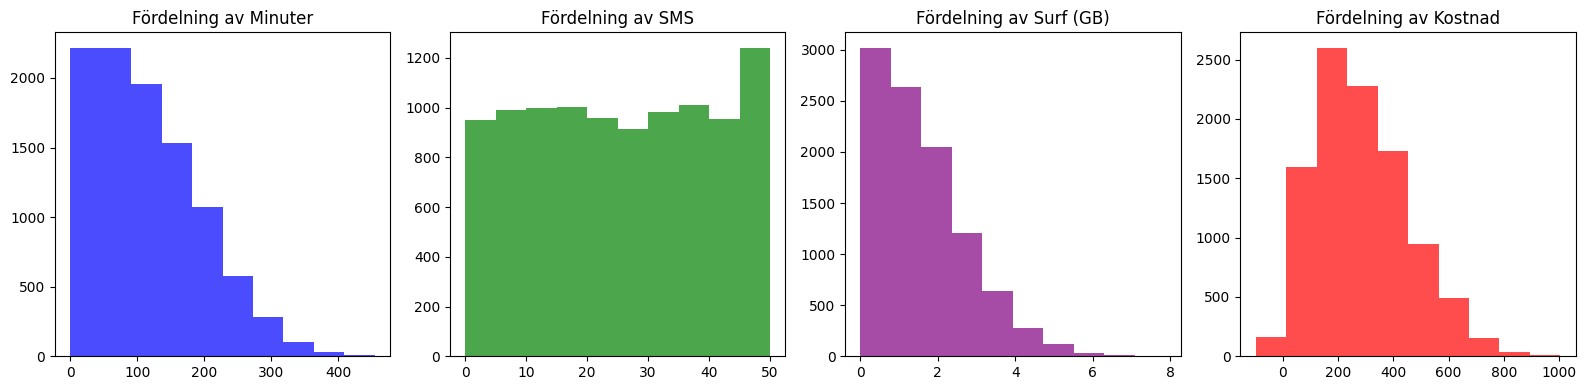

In [28]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 4, figsize=(16, 4))


axes[0].hist(df['Minuter'], bins=10, color='blue', alpha=0.7)
axes[0].set_title('Fördelning av Minuter')


axes[1].hist(df['SMS'], bins=10, color='green', alpha=0.7)
axes[1].set_title('Fördelning av SMS')


axes[2].hist(df['Surf (GB)'], bins=10, color='purple', alpha=0.7)
axes[2].set_title('Fördelning av Surf (GB)')


axes[3].hist(df['Kostnad'], bins=10, color='red', alpha=0.7)
axes[3].set_title('Fördelning av Kostnad')

plt.tight_layout()
plt.show()


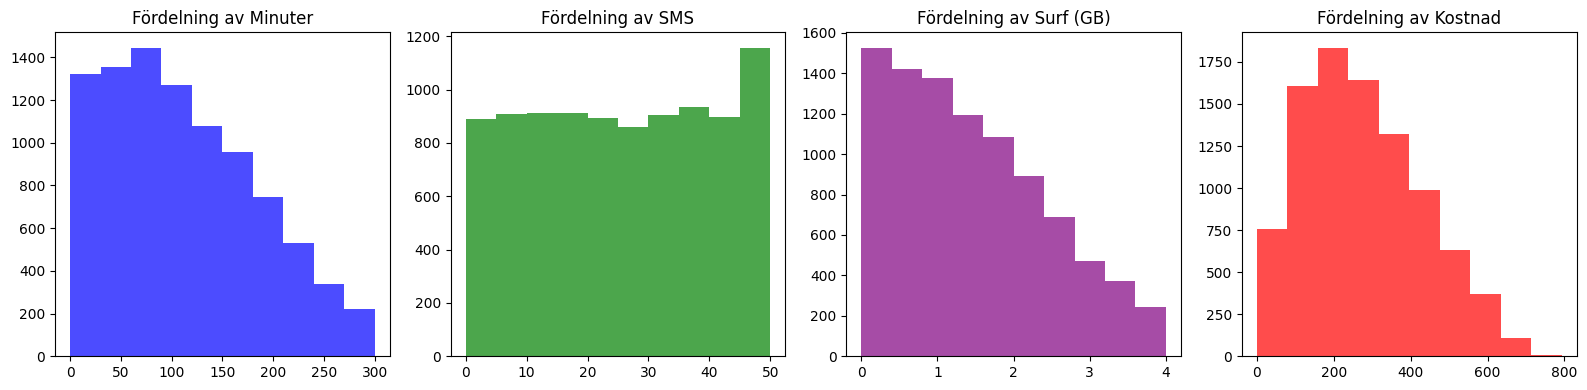

In [29]:
# Vi delar upp våra data i features (X) och target values(y).

X = df[['Intercept', 'Minuter', 'SMS', 'Surf (GB)']]
y = df['Kostnad']

# Jag filtrerar datan baserat på villkoren i uppgiften.
# OBS: Bra att komma ihåg att man kan ha villkor som dessa för att filtrera data.
df = df[(df['Surf (GB)'] < 4) & 
        (df['Minuter'] < 300) & 
        (df['Kostnad'] > 0)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].hist(df['Minuter'], bins=10, color='blue', alpha=0.7)
axes[0].set_title('Fördelning av Minuter')


axes[1].hist(df['SMS'], bins=10, color='green', alpha=0.7)
axes[1].set_title('Fördelning av SMS')


axes[2].hist(df['Surf (GB)'], bins=10, color='purple', alpha=0.7)
axes[2].set_title('Fördelning av Surf (GB)')


axes[3].hist(df['Kostnad'], bins=10, color='red', alpha=0.7)
axes[3].set_title('Fördelning av Kostnad')

plt.tight_layout()
plt.show()



## 5. Multiple linear regression (*)

&nbsp; a) Perform a train|test split with 0.8 of the data for training. (*)

&nbsp; b) Use the normal equation to compute $\hat{\beta}$ (*)

&nbsp; c) Predict on the test data and compute MAE, MSE and RMSE. (*)

&nbsp; d) Now repeat 4a), 4c), 5a), 5b) using 10, 100, 1000, 10000, 100000, 1000000 samples, and calculate RMSE for each of these simulations. Plot the RMSE against sample size. (**)


<details>

<summary>Hint</summary>

It is important to keep track of the shapes of the vectors, matrices in order for matrix multiplication matmul "@" to work correctly. Also, if you have series object, you need to convert it to numpy. 

</details>

<br/>

<details>
<summary>Answer</summary>


<img src="../assets/RMSE_simulation.png" height="200"/>

</details>

Sample size: 10, RMSE: 124.9115
Sample size: 100, RMSE: 50.2761
Sample size: 1000, RMSE: 52.8483
Sample size: 10000, RMSE: 49.7382
Sample size: 100000, RMSE: 9.6130


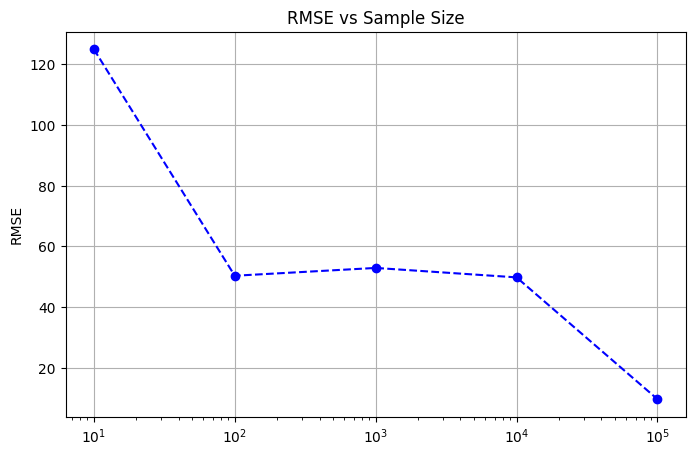

In [30]:

X_train, X_test, y_train, y_test = train_test_split(df[['Minuter']], df['Kostnad'], train_fraction = 0.8)

beta0, beta1 = normal_equation(X_train, y_train)

y_pred = predict(X_test, beta0, beta1)

MAE = np.mean(np.abs(y_pred - y_test))
MSE = np.mean((y_pred - y_test) ** 2)
RMSE = np.sqrt(MSE)


def evaluate_sample_size(sample_size):
    df_sample = df[['Minuter', 'SMS', 'Surf (GB)', 'Kostnad']].sample(n=sample_size, random_state=42, replace=True)

    X_train, X_test, y_train, y_test = train_test_split(
        df_sample[['Minuter', 'SMS', 'Surf (GB)']], 
        df_sample['Kostnad'], 
        train_fraction=0.8
    )


    X_train = np.c_[np.ones(X_train.shape[0]), X_train]
    X_test = np.c_[np.ones(X_test.shape[0]), X_test]


    beta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)


 
    y_pred = np.matmul(X_test, beta)



    RMSE = np.sqrt(np.mean((y_pred - y_test) ** 2))
    
    return RMSE

sample_sizes = [10, 100, 1000, 10000, 100000]

rmse_values = []


for size in sample_sizes:
    rmse = evaluate_sample_size(size)
    rmse_values.append(rmse)
    print(f"Sample size: {size}, RMSE: {rmse:.4f}")


plt.figure(figsize=(8,5))
plt.plot(sample_sizes, rmse_values, marker='o', linestyle='--', color='b')
plt.xscale('log') 
plt.ylabel("RMSE")
plt.title("RMSE vs Sample Size")
plt.grid(True)
plt.show()



---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---